In [1]:
import cfg
from libs.data_request import DataRequest
from libs.analysis import PSDHistogram

log = cfg.set_logger()
dr = DataRequest(log=log, base_url=cfg.API_URL)

camp_ids = {'FM': 176}
target_nodes = [1, 2, 3, 4, 5, 6, 7, 9, 10]

[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api


In [2]:
import redis
import pickle

r = redis.Redis()

if r.exists('df_full'):
    df_full = pickle.loads(r.get('df_full'))
else:
    df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)
    r.set('df_full', pickle.dumps(df_full))

datos_nodos = df_full["FM"]
#Initialize the analyzer
analyzer = PSDHistogram(datos_nodos, global_range=(-27, 6))

Parsing pxx across 9 nodes for Histograms...


100%|██████████| 9/9 [00:02<00:00,  3.37it/s]


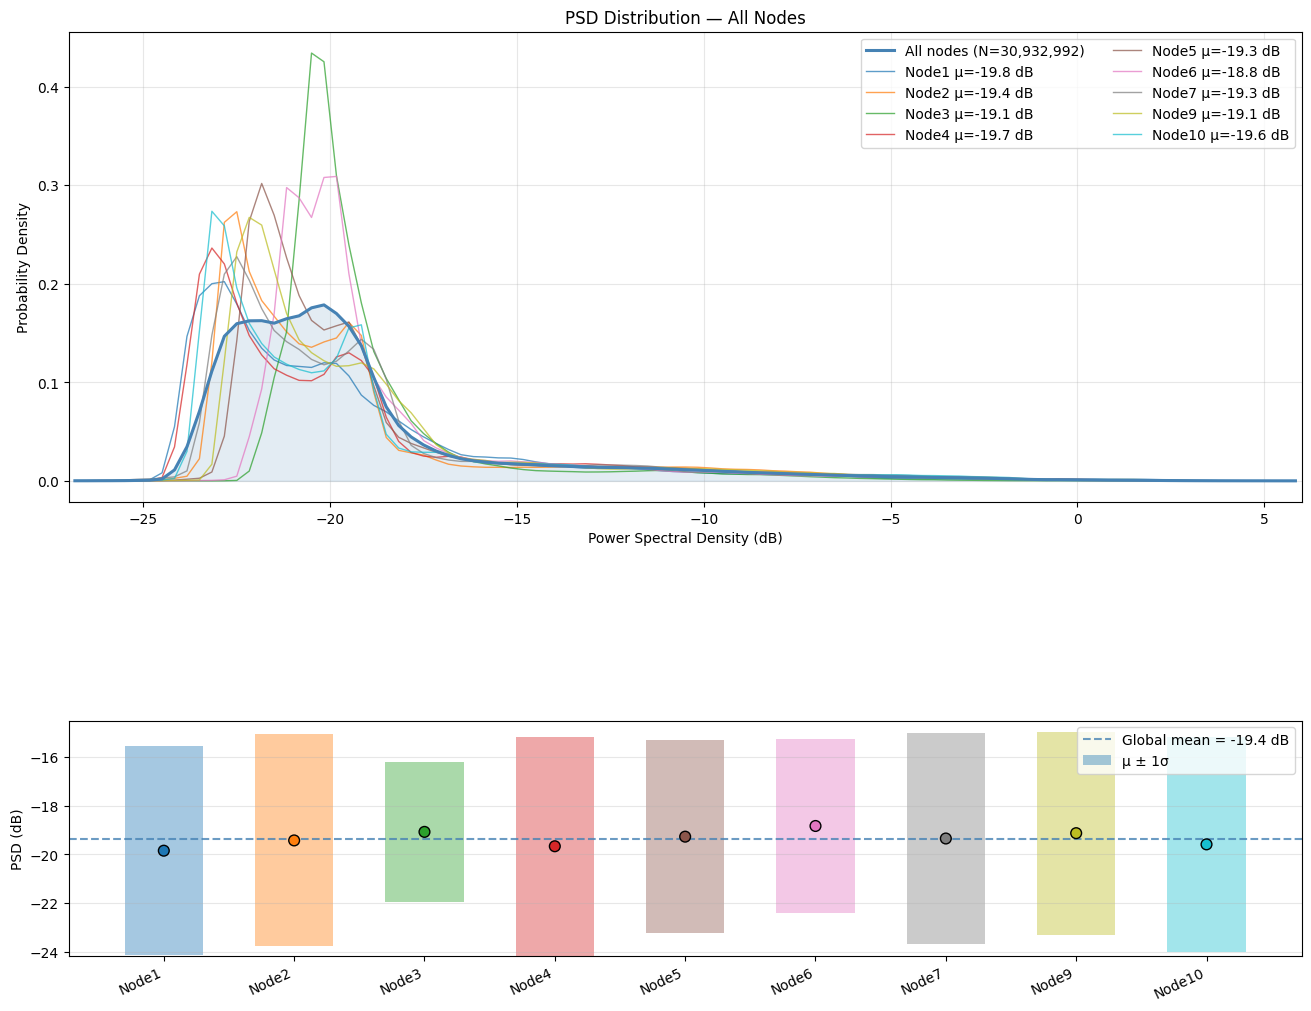

In [3]:
#Execute Histogram Analysis
# This parses all rows, calculates densities, and plots Panel A (Overlay) and Panel B (Mean/Std)
analyzer.execute_histogram()


Computing Mutual Information Matrix (Single Row Alignment)...


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 103.47it/s]


 Nodes ranked by Product Score:
Rank   Label                Corr         MI           Product     
----------------------------------------------------------------------
1      Node10                    0.7748      1.0000      0.8874
2      Node2                     0.8183      0.9457      0.8820
3      Node7                     0.8331      0.9072      0.8702
4      Node4                     0.7546      0.9703      0.8625
5      Node5                     0.7639      0.8753      0.8196
6      Node1                     0.7683      0.8503      0.8093
7      Node6                     0.6507      0.6154      0.6330
8      Node9                     0.7796      0.2017      0.4906
9      Node3                     0.5839      0.3815      0.4827


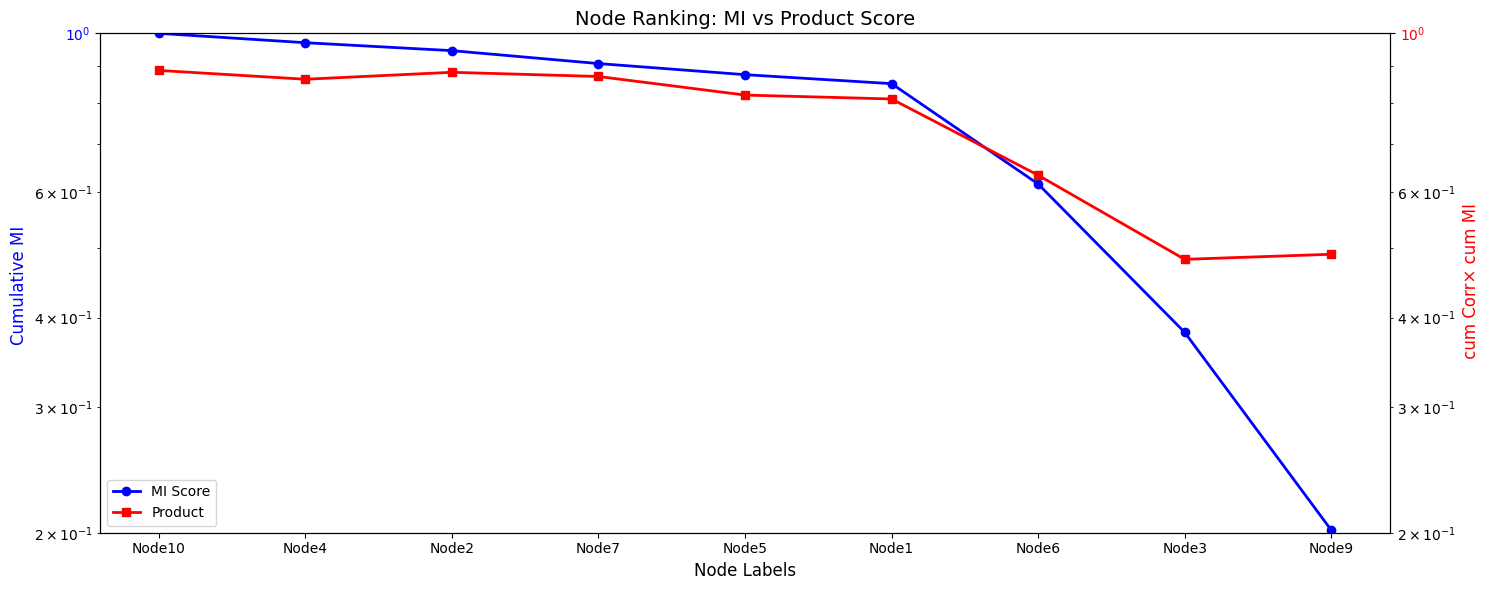

In [4]:
# Execute Cumulative Ranking
# This aligns single-row vectors for MI, calculates the correlation matrix from densities,
# computes the weighted product (alpha=0.5), prints the rank table, and shows the log-scale plot.
analyzer.exec_cumm_ranking(normalized=False, alpha=0.5)